In [1]:
# Necessary packages 
!pip install seaborn
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Essential Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [3]:
# Project: European Championship Match Statistics and Outcomes
#
# Objective:
# Explore associations between possession, shots, fouls,
# and match outcomes.
#
# Train logistic regression using completed-match statistics
# to classify home wins versus home non-wins.
#
# Evaluate on later-year matches against a simple baseline.
#
# Data source: Kaggle
# Dataset URL: https://www.kaggle.com/datasets/kaito510/uefa-euro-stats-possession-shots-on-goal-etc

In [4]:
# Load Dataset
df = pd.read_csv("data/EuroAllMatchBoxData.csv")

# Keep matches with valid possession recorded for both teams.
valid_possession = (
    df["hPossesion"].between(1, 99)
    & df["aPossesion"].between(1, 99)
    & ((df["hPossesion"] + df["aPossesion"]) == 100)
)

subset_df = df.loc[valid_possession].copy()

print("Original matches:", len(df))
print("Matches kept:", len(subset_df))
print("Matches excluded:", len(df) - len(subset_df))

Original matches: 1397
Matches kept: 1127
Matches excluded: 270


Possession values of zero were treated as missing or invalid.Analysis was restricted to matches where both teams had positivepossession values summing to 100%. Zero shots and shots on targetwere retained because they can be legitimate.

In [5]:




df["goal_difference"] = abs(df["hgoals"] - df["agoals"])
df.head()

,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,ashots,hyellowCards,ayellowCards,hredCards,aredCards,hfouls,afouls,hsaves,asaves,goal_difference
0,2002,Faroe Islands,Scotland,2,2,0,0,0,0,0,0,2,3,0,0,0,0,0,0,0
1,2002,Norway,Denmark,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2002,Armenia,Ukraine,2,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2002,Russia,Republic of Ireland,4,2,0,0,0,0,0,0,1,0,0,0,0,0,0,0,2
4,2002,Cyprus,France,1,2,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1


In [6]:
num_rows = len(df)
print(num_rows)

1397


In [7]:
# Quick test for correlation between column variables
subset_df[["hshots", "hfouls", "hshotsOnTarget", "hgoals"]].corr()

,hshots,hfouls,hshotsOnTarget,hgoals
hshots,1.000000,-0.055944,0.800259,0.503736
hfouls,-0.055944,1.000000,-0.073028,-0.148098
hshotsOnTarget,0.800259,-0.073028,1.000000,0.570935
hgoals,0.503736,-0.148098,0.570935,1.000000


In [8]:
# Function for creating match result column
def match_result(row):
    if row['hgoals'] > row['agoals']:
        return 'Home win'
    elif row['agoals'] > row['hgoals']:
        return 'Away win'
    else:
        return 'Draw'
subset_df['result'] = subset_df.apply(match_result, axis = 1)

In [9]:
subset_df.head()

,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,ashots,hyellowCards,ayellowCards,hredCards,aredCards,hfouls,afouls,hsaves,asaves,result
202,2004,Portugal,Greece,1,2,50,50,8,3,18,5,2,3,0,0,15,18,2,6,Away win
203,2004,Spain,Russia,1,0,61,39,8,5,16,8,3,5,0,1,10,19,5,9,Home win
204,2004,Switzerland,Croatia,0,0,41,59,6,7,10,18,3,5,1,0,22,15,9,5,Draw
205,2004,France,England,2,1,52,48,6,2,16,6,2,3,0,0,16,18,2,8,Home win
206,2004,Denmark,Italy,0,0,54,46,9,4,10,8,2,4,0,0,10,13,7,6,Draw


In [10]:
# Creates new column that determines which team has more shots
def more_shots(row):
    if row['hshots'] > row['ashots']:
        return 'Home'
    elif row['ashots'] > row['hshots']:
        return 'Away'
    else:
        return 'Equal'
subset_df['more_shots_team'] = df.apply(more_shots, axis = 1)
subset_df.head()

,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,...,hyellowCards,ayellowCards,hredCards,aredCards,hfouls,afouls,hsaves,asaves,result,more_shots_team
202,2004,Portugal,Greece,1,2,50,50,8,3,18,...,2,3,0,0,15,18,2,6,Away win,Home
203,2004,Spain,Russia,1,0,61,39,8,5,16,...,3,5,0,1,10,19,5,9,Home win,Home
204,2004,Switzerland,Croatia,0,0,41,59,6,7,10,...,3,5,1,0,22,15,9,5,Draw,Away
205,2004,France,England,2,1,52,48,6,2,16,...,2,3,0,0,16,18,2,8,Home win,Home
206,2004,Denmark,Italy,0,0,54,46,9,4,10,...,2,4,0,0,10,13,7,6,Draw,Home


In [11]:
# New column that returns a true or false value based on whether the team with more shots won or lost
subset_df['shots_team_won'] = (((subset_df['more_shots_team'] == 'Home') & (subset_df['result'] == 'Home win')) | ((subset_df['more_shots_team'] == 'Away') & (subset_df['result'] == 'Away win')))

In [12]:
subset_df.head()

,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,...,ayellowCards,hredCards,aredCards,hfouls,afouls,hsaves,asaves,result,more_shots_team,shots_team_won
202,2004,Portugal,Greece,1,2,50,50,8,3,18,...,3,0,0,15,18,2,6,Away win,Home,False
203,2004,Spain,Russia,1,0,61,39,8,5,16,...,5,0,1,10,19,5,9,Home win,Home,True
204,2004,Switzerland,Croatia,0,0,41,59,6,7,10,...,5,1,0,22,15,9,5,Draw,Away,False
205,2004,France,England,2,1,52,48,6,2,16,...,3,0,0,16,18,2,8,Home win,Home,True
206,2004,Denmark,Italy,0,0,54,46,9,4,10,...,4,0,0,10,13,7,6,Draw,Home,False


In [13]:
shot_win_rate = subset_df['shots_team_won'].mean() * 100
shot_win_rate

np.float64(61.84560780834073)

In [14]:
# Creates new column that shows the difference in possession between the home and away teams
subset_df['possession_diff'] = subset_df['hPossesion'] - subset_df['aPossesion']
subset_df.head()


,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,...,hredCards,aredCards,hfouls,afouls,hsaves,asaves,result,more_shots_team,shots_team_won,possession_diff
202,2004,Portugal,Greece,1,2,50,50,8,3,18,...,0,0,15,18,2,6,Away win,Home,False,0
203,2004,Spain,Russia,1,0,61,39,8,5,16,...,0,1,10,19,5,9,Home win,Home,True,22
204,2004,Switzerland,Croatia,0,0,41,59,6,7,10,...,1,0,22,15,9,5,Draw,Away,False,-18
205,2004,France,England,2,1,52,48,6,2,16,...,0,0,16,18,2,8,Home win,Home,True,4
206,2004,Denmark,Italy,0,0,54,46,9,4,10,...,0,0,10,13,7,6,Draw,Home,False,8


In [15]:
subset_df["possession_diff"] = (
    subset_df["hPossesion"] - subset_df["aPossesion"]
)

# Exclude equal-possession matches.
possession_matches = subset_df.loc[
    subset_df["possession_diff"] != 0
].copy()

possession_matches["possession_advantage"] = (
    possession_matches["possession_diff"].abs()
)

possession_matches["more_possession_team_won"] = (
    (
        (possession_matches["possession_diff"] > 0)
        & (possession_matches["result"] == "Home win")
    )
    | (
        (possession_matches["possession_diff"] < 0)
        & (possession_matches["result"] == "Away win")
    )
)

possession_matches["possession_range"] = pd.cut(
    possession_matches["possession_advantage"],
    bins=[0, 10, 20, float("inf")],
    labels=["Under 10", "10–under 20", "20+"],
    right=False
)

possession_summary = (
    possession_matches.groupby("possession_range", observed=True)
    ["more_possession_team_won"]
    .agg(matches="count", wins="sum", win_rate="mean")
)

possession_summary["win_percentage"] = (
    possession_summary["win_rate"] * 100
)

print(
    possession_summary[["matches", "wins", "win_percentage"]]
)
print(
    "Equal-possession matches excluded:",
    (subset_df["possession_diff"] == 0).sum()
)

                  matches  wins  win_percentage
possession_range                               
Under 10              287   127       44.250871
10–under 20           272   156       57.352941
20+                   369   265       71.815718
Equal-possession matches excluded: 199


In [16]:
possession_summary[["matches", "wins", "win_percentage"]]

,matches,wins,win_percentage
possession_range,,,
Under 10,287,127,44.250871
10–under 20,272,156,57.352941
20+,369,265,71.815718


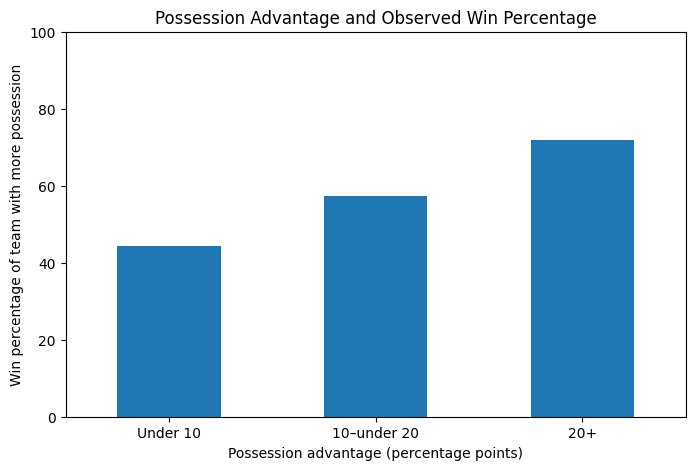

In [17]:
possession_summary["win_percentage"].plot(
    kind="bar", figsize=(8, 5)
)

plt.xlabel("Possession advantage (percentage points)")
plt.ylabel("Win percentage of team with more possession")
plt.title("Possession Advantage and Observed Win Percentage")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

Among matches with unequal possession, teams with an advantage under 10 percentage points won 44.3% of matches, compared with 57.4% for an advantage of 10–under 20 points and 71.8% for 20+ points. Draws counted as non-wins, and 199 equal-possession matches were excluded. Larger possession advantages were associated with higher win rates; team strength and match circumstances could also contribute to this pattern.

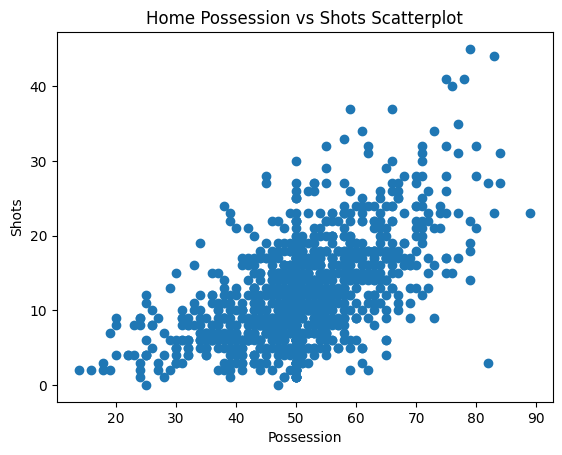

In [18]:


# Scatterplot to show correlation between home teams possession and shots 
x = subset_df['hPossesion']
y = subset_df['hshots']
plt.scatter(x,y)
plt.xlabel("Possession")
plt.ylabel("Shots")
plt.title("Home Possession vs Shots Scatterplot")
plt.show()

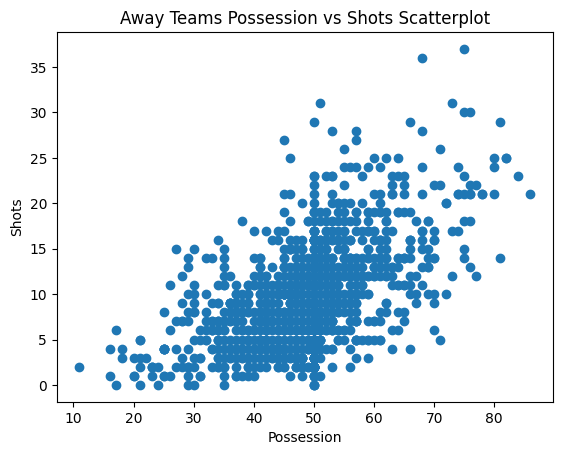

In [19]:
# Scatterplot to show correlation between away teams possession and shots 
x = subset_df['aPossesion']
y = subset_df['ashots']
plt.scatter(x,y)
plt.xlabel("Possession")
plt.ylabel("Shots")
plt.title("Away Teams Possession vs Shots Scatterplot")
plt.show()

result
Home win    515
Away win    400
Draw        212
Name: count, dtype: int64


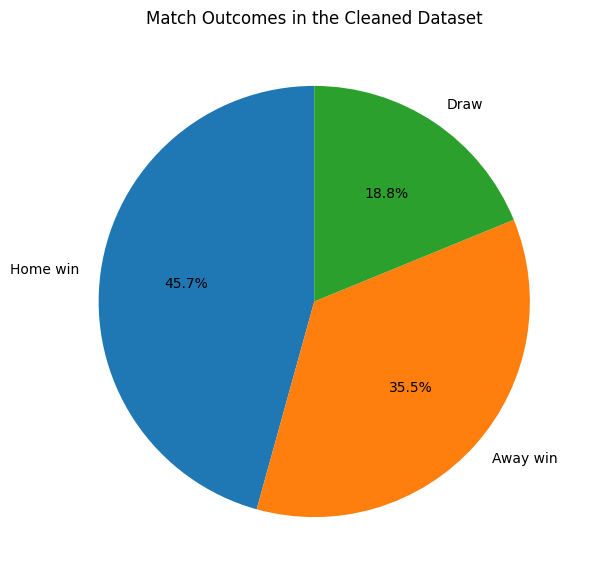

In [20]:
# Classify each match using the recorded goal totals.
def match_result(row):
    if row["hgoals"] > row["agoals"]:
        return "Home win"
    elif row["agoals"] > row["hgoals"]:
        return "Away win"
    return "Draw"

subset_df["result"] = subset_df.apply(match_result, axis=1)

result_count = subset_df["result"].value_counts()
print(result_count)

plt.figure(figsize=(7, 7))
plt.pie(
    result_count,
    labels=result_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Match Outcomes in the Cleaned Dataset")
plt.show()

This chart compares outcomes for the listed home and away teams. It does not establish home-field advantage, because the listed home team may not be playing in its own country.

In [21]:
subset_df["shot_diff"] = (
    subset_df["hshots"] - subset_df["ashots"]
)

# Exclude equal-shot matches: neither team had more shots.
shot_matches = subset_df.loc[
    subset_df["shot_diff"] != 0
].copy()

shot_matches["shot_advantage"] = (
    shot_matches["shot_diff"].abs()
)

shot_matches["more_shots_team_won"] = (
    (
        (shot_matches["shot_diff"] > 0)
        & (shot_matches["result"] == "Home win")
    )
    | (
        (shot_matches["shot_diff"] < 0)
        & (shot_matches["result"] == "Away win")
    )
)

shot_matches["shot_range"] = pd.cut(
    shot_matches["shot_advantage"],
    bins=[1, 5, 10, float("inf")],
    labels=["1–4", "5–9", "10+"],
    right=False
)

shot_summary = (
    shot_matches.groupby("shot_range", observed=True)
    ["more_shots_team_won"]
    .agg(matches="count", wins="sum", win_rate="mean")
)

shot_summary["win_percentage"] = (
    shot_summary["win_rate"] * 100
)

print(shot_summary[["matches", "wins", "win_percentage"]])
print("Equal-shot matches excluded:",
      (subset_df["shot_diff"] == 0).sum())

            matches  wins  win_percentage
shot_range                               
1–4             312   164       52.564103
5–9             359   213       59.331476
10+             414   320       77.294686
Equal-shot matches excluded: 42


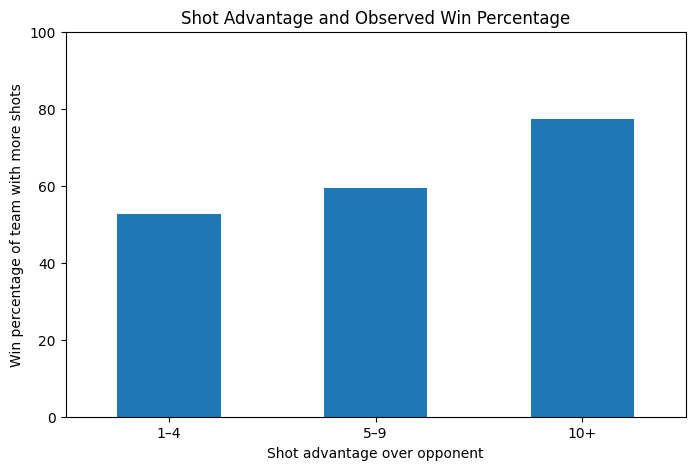

In [22]:
shot_summary["win_percentage"].plot(
    kind="bar", figsize=(8, 5)
)

plt.xlabel("Shot advantage over opponent")
plt.ylabel("Win percentage of team with more shots")
plt.title("Shot Advantage and Observed Win Percentage")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.show()

Among matches with unequal shot totals, teams with 1–4 more shots won 52.6% of matches, compared with 59.3% for 5–9 and 77.3% for 10+. Draws counted as non-wins, and 42 equal-shot matches were excluded. Larger shot advantages were associated with higher win rates; this analysis does not establish causation.

                 matches  wins  win_percentage
home_foul_range                               
0–7                  200   106       53.000000
8–11                 377   184       48.806366
12–15                339   146       43.067847
16–19                142    57       40.140845
20+                   69    22       31.884058


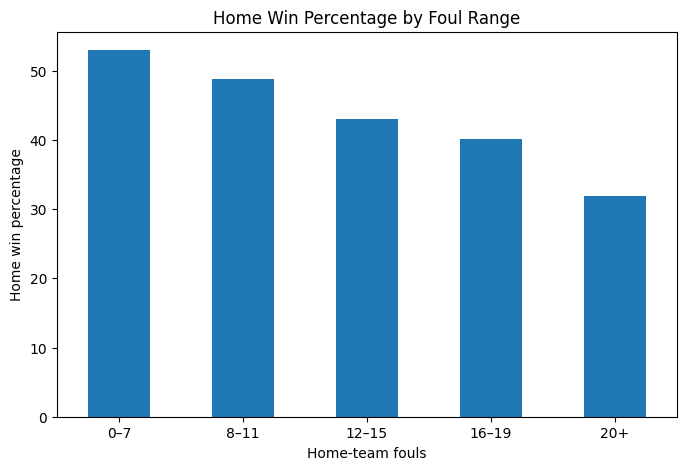

In [23]:
# Whether the home team won; draws count as non-wins.
subset_df["home_win"] = (
    subset_df["hgoals"] > subset_df["agoals"]
)

# Ranges: 0–7, 8–11, 12–15, 16–19, and 20+.
bins = [0, 8, 12, 16, 20, float("inf")]
labels = ["0–7", "8–11", "12–15", "16–19", "20+"]

subset_df["home_foul_range"] = pd.cut(
    subset_df["hfouls"],
    bins=bins,
    labels=labels,
    right=False
)

foul_summary = (
    subset_df.groupby("home_foul_range", observed=True)
    ["home_win"]
    .agg(matches="count", wins="sum", win_rate="mean")
)

foul_summary["win_percentage"] = (
    foul_summary["win_rate"] * 100
)

print(foul_summary[["matches", "wins", "win_percentage"]])

foul_summary["win_percentage"].plot(
    kind="bar", figsize=(8, 5)
)
plt.xlabel("Home-team fouls")
plt.ylabel("Home win percentage")
plt.title("Home Win Percentage by Foul Range")
plt.xticks(rotation=0)
plt.show()
                     

In this dataset, home teams with fewer fouls had higher observed win percentages. Teams committing 0–7 fouls won 53.0% of matches, compared with 31.9% for teams committing 20 or more. This association does not establish that reducing fouls causes more wins.

                 matches  wins  win_percentage
away_foul_range                               
0–7                  191    83       43.455497
8–11                 350   128       36.571429
12–15                342   111       32.456140
16–19                178    61       34.269663
20+                   66    17       25.757576


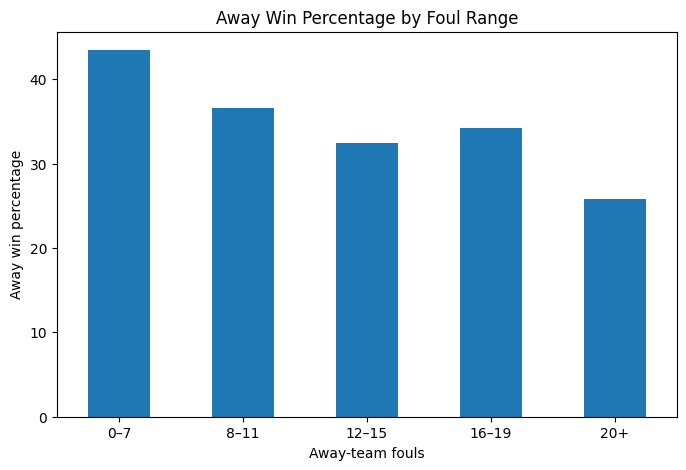

In [24]:
# Grouping away team fouls into ranges and then relating these ranges to the amount of wins they correspond to
subset_df["away_win"] = (
    subset_df["agoals"] > subset_df["hgoals"]
)

bins = [0, 8, 12, 16, 20, float("inf")]
labels = ["0–7", "8–11", "12–15", "16–19", "20+"]

subset_df["away_foul_range"] = pd.cut(
    subset_df["afouls"],
    bins=bins,
    labels=labels,
    right=False
)

away_foul_summary = (
    subset_df.groupby("away_foul_range", observed=True)
    ["away_win"]
    .agg(matches="count", wins="sum", win_rate="mean")
)

away_foul_summary["win_percentage"] = (
    away_foul_summary["win_rate"] * 100
)

print(
    away_foul_summary[["matches", "wins", "win_percentage"]]
)

away_foul_summary["win_percentage"].plot(
    kind="bar", figsize=(8, 5)
)
plt.xlabel("Away-team fouls")
plt.ylabel("Away win percentage")
plt.title("Away Win Percentage by Foul Range")
plt.xticks(rotation=0)
plt.show()

Away teams committing 0–7 fouls had the highest observed win percentage (43.5%), while teams committing 20+ had the lowest (25.8%). The pattern generally decreased across foul ranges, with a small increase at 16–19. These results show an association, not evidence that fewer fouls cause more wins.

In [25]:
subset_df.head()

,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,...,asaves,result,more_shots_team,shots_team_won,possession_diff,shot_diff,home_win,home_foul_range,away_win,away_foul_range
202,2004,Portugal,Greece,1,2,50,50,8,3,18,...,6,Away win,Home,False,0,13,False,12–15,True,16–19
203,2004,Spain,Russia,1,0,61,39,8,5,16,...,9,Home win,Home,True,22,8,True,8–11,False,16–19
204,2004,Switzerland,Croatia,0,0,41,59,6,7,10,...,5,Draw,Away,False,-18,-8,False,20+,False,12–15
205,2004,France,England,2,1,52,48,6,2,16,...,8,Home win,Home,True,4,10,True,16–19,False,16–19
206,2004,Denmark,Italy,0,0,54,46,9,4,10,...,6,Draw,Home,False,8,2,False,8–11,False,12–15


In [26]:
subset_df.head()

,year,hname,aname,hgoals,agoals,hPossesion,aPossesion,hshotsOnTarget,ashotsOnTarget,hshots,...,asaves,result,more_shots_team,shots_team_won,possession_diff,shot_diff,home_win,home_foul_range,away_win,away_foul_range
202,2004,Portugal,Greece,1,2,50,50,8,3,18,...,6,Away win,Home,False,0,13,False,12–15,True,16–19
203,2004,Spain,Russia,1,0,61,39,8,5,16,...,9,Home win,Home,True,22,8,True,8–11,False,16–19
204,2004,Switzerland,Croatia,0,0,41,59,6,7,10,...,5,Draw,Away,False,-18,-8,False,20+,False,12–15
205,2004,France,England,2,1,52,48,6,2,16,...,8,Home win,Home,True,4,10,True,16–19,False,16–19
206,2004,Denmark,Italy,0,0,54,46,9,4,10,...,6,Draw,Home,False,8,2,False,8–11,False,12–15


In [27]:
print((subset_df['result'] == 'Home win').sum())

515


In [28]:
print(subset_df.dtypes)

year                  int64
hname                object
aname                object
hgoals                int64
agoals                int64
hPossesion            int64
aPossesion            int64
hshotsOnTarget        int64
ashotsOnTarget        int64
hshots                int64
ashots                int64
hyellowCards          int64
ayellowCards          int64
hredCards             int64
aredCards             int64
hfouls                int64
afouls                int64
hsaves                int64
asaves                int64
result               object
more_shots_team      object
shots_team_won         bool
possession_diff       int64
shot_diff             int64
home_win               bool
home_foul_range    category
away_win               bool
away_foul_range    category
dtype: object


In [29]:
print(subset_df['result'].unique())

['Away win' 'Home win' 'Draw']


In [30]:
print(subset_df['result'].describe())

count         1127
unique           3
top       Home win
freq           515
Name: result, dtype: object


In [31]:
def match_result(row):
    if row['hgoals'] > row['agoals']:
        return 'Home win'
    elif row['agoals'] > row['hgoals']:
        return 'Away win'
    else:
        return 'Draw'
subset_df['result'] = subset_df.apply(match_result, axis = 1)


In [32]:

# Target: home win = 1; away win or draw = 0.
subset_df["win"] = (
    subset_df["hgoals"] > subset_df["agoals"]
).astype(int)

features = ["hshotsOnTarget", "hPossesion", "hfouls"]

# Train on earlier matches; test on later matches.
train_df = subset_df.loc[subset_df["year"] < 2019].copy()
test_df = subset_df.loc[subset_df["year"] >= 2019].copy()

X_train = train_df[features]
y_train = train_df["win"]

X_test = test_df[features]
y_test = test_df["win"]

print("Training matches:", len(train_df))
print("Testing matches:", len(test_df))
print("Training years:",
      train_df["year"].min(), "–", train_df["year"].max())
print("Testing years:",
      test_df["year"].min(), "–", test_df["year"].max())



Training matches: 845
Testing matches: 282
Training years: 2004 – 2016
Testing years: 2019 – 2021


In [33]:
# Selecting logistic regression and running it with data 
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
# Setting up the prediction models
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


In [35]:
# How accurate our model predictions are
accuracy = accuracy_score(y_test, y_pred)

# Baseline: always predict the most common training outcome.
baseline_prediction = int(y_train.mode().iloc[0])
baseline_pred = np.full(len(y_test), baseline_prediction)
baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Model accuracy: {accuracy:.1%}")
print(f"Baseline accuracy: {baseline_accuracy:.1%}")
print("Baseline predicts:",
      "Home win" if baseline_prediction == 1
      else "Home non-win")

Model accuracy: 77.3%
Baseline accuracy: 53.5%
Baseline predicts: Home non-win


In [36]:
# Confusion matrix for our model
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

cm_table = pd.DataFrame(
    cm,
    index=["Actual home non-win", "Actual home win"],
    columns=["Predicted home non-win", "Predicted home win"]
)

print(cm_table)
print()
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Home non-win", "Home win"],
    zero_division=0
))

                     Predicted home non-win  Predicted home win
Actual home non-win                     131                  20
Actual home win                          44                  87

              precision    recall  f1-score   support

Home non-win       0.75      0.87      0.80       151
    Home win       0.81      0.66      0.73       131

    accuracy                           0.77       282
   macro avg       0.78      0.77      0.77       282
weighted avg       0.78      0.77      0.77       282



### Model evaluation

Logistic regression was trained on 845 matches from 2004–2016
and tested on 282 matches from 2019–2021.

The model achieved 77.3% accuracy, compared with 53.5% for a
baseline that always predicted a home non-win.

Home-win precision was 81%, and recall was 66%. The model
missed 44 actual home wins and incorrectly predicted 20
home wins.

The inputs were full-match home-team shots on target,
possession, and fouls. These results describe classification
using completed-match statistics, rather than prediction
before kickoff. Draws and away wins were grouped as home
non-wins.

In [37]:
# Predicting the outcome for a match with a home team with 10 shots on target, 70% possession, and 11 fouls
# Example using completed-match home-team statistics.
example_match = pd.DataFrame(
    [{
        "hshotsOnTarget": 10,
        "hPossesion": 70,
        "hfouls": 11
    }]
)

example_prediction = model.predict(example_match)[0]

print(
    "Predicted outcome:",
    "Home win" if example_prediction == 1
    else "Home non-win"
)

Predicted outcome: Home win


In [38]:
example_probability = model.predict_proba(example_match)[0, 1]

print(
    f"Model-estimated probability of a home win: "
    f"{example_probability:.1%}"
)


Model-estimated probability of a home win: 87.7%


### Limitations

- The dataset appears to include both qualifiers and tournament
  finals. Competition stages and match coverage need verification
  against the original source.

- The listed home team may not be playing in its own country,
  so home/away outcome differences do not establish home-field
  advantage.

- Excluding 270 matches with missing or invalid possession may
  affect how representative the analyzed sample is. Other
  statistics may also contain missing values requiring checks.

- Possession, shots, and fouls are measured during the match.
  Their associations with winning do not establish causation.

- The model uses completed-match statistics, so its performance
  does not measure forecasting ability before kickoff.

- Draws and away wins are grouped as home non-wins. Outcomes
  use recorded goal totals; extra time and penalty shootouts
  need verification against the source.

- Model probabilities have not been checked for calibration.

### Key Findings

The cleaned dataset contains 1,127 matches.

- Teams with a shot advantage of 1–4 won 52.6% of matches,
  compared with 59.3% for 5–9 and 77.3% for 10+.
  Equal-shot matches were excluded; draws counted as non-wins.

- Teams with a possession advantage under 10 percentage points
  won 44.3% of matches, compared with 57.4% for 10–under 20
  and 71.8% for 20+. Equal-possession matches were excluded;
  draws counted as non-wins.

- The 0–7 foul range had the highest observed win percentage
  for both home teams (53.0%) and away teams (43.5%).
  These results do not support the original claim that
  8–11 fouls is an ideal range.

- Logistic regression achieved 77.3% accuracy on 282
  later-year matches, compared with 53.5% for the baseline.
  It used completed-match statistics to classify home wins
  versus home non-wins.